## What is Clustering?

- Clustering is an Unsupervised Machine Learning technique used to group similar data points together.Unlike supervised learning, there are no labels (target values).

The algorithm discovers hidden patterns by itself.

## What is K-Means?
- K-Means is an unsupervised learning algorithm that partitions data into K clusters by minimizing the distance between data points and their assigned cluster centroid.
- It is an unsupervised learning algorithm because it does not use labeled data.

## What is a Centroid?
- Centroid is the center point of a cluster.
- It is not necessarily an actual data point.

## 3. Why is it called K-Means?
- Because K = Number of clusters ,Means = Mean (Average) of the points inside each cluster.

## What is WCSS?

- Answer: The total squared distance between each data point and its assigned centroid.

## What is the objective function of K-Means?

- Answer: To minimize WCSS (also known as SSE or inertia).


- ❌ "K-Means minimizes the average distance."
✔️ It minimizes the sum of squared distances (WCSS).
- The most common distance metric used by K-Means is Euclidean Distance.
- ❌ Keeping centroids as integers instead of floats.

### Why use np.argmin()?
- Answer: It returns the index of the smallest distance, which corresponds to the nearest centroid.

### Why use max_iterations?
- Answer: To prevent infinite loops if the algorithm does not converge within a reasonable number of iterations.

### What does fit() do?
- Answer: It learns cluster assignments and computes the final centroids from the training data.

| fit()            | predict()                                           |
| ---------------- | --------------------------------------------------- |
| Learns centroids | Assigns new samples to the nearest learned centroid |

### What is cluster_centers_?
- Answer: The coordinates of the final centroids after convergence.

### What is inertia_?
- Answer: The Within-Cluster Sum of Squares (WCSS), which K-Means minimizes.

```bash
KMeans() দিয়ে সহজেই clustering করা যায়।
fit() মডেলকে train করে এবং centroid শিখে।
predict() নতুন data কোন cluster-এ যাবে তা বলে।
labels_ প্রতিটি training sample-এর cluster ID দেয়।
cluster_centers_ final centroid-এর অবস্থান দেয়।
inertia_ হলো WCSS।
Feature scaling (যেমন StandardScaler) প্রায় সব সময় করা উচিত।
k-means++ initialization সাধারণত random-এর চেয়ে ভালো।
```

[0 0 0 1 1 1]
[[1.33333333 1.33333333]
 [8.33333333 8.66666667]]


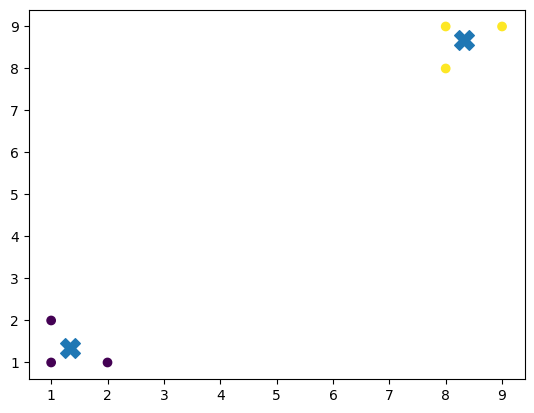

In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Sample data
X = [
    [1, 2],
    [2, 1],
    [1, 1],
    [8, 8],
    [9, 9],
    [8, 9]
]

# Create model
model = KMeans(
    n_clusters=2,
    random_state=42
)

# Train
model.fit(X)

# Cluster labels
print(model.labels_)

# Centroids
print(model.cluster_centers_)

# Visualization
plt.scatter(
    [x[0] for x in X],
    [x[1] for x in X],
    c=model.labels_
)

plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[:,1],
    marker='X',
    s=200
)

plt.show()

In [2]:
import numpy as np
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=300,
    centers=4,
    random_state=42
)

In [3]:
from sklearn.cluster import KMeans


wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X)

    wcss.append(model.inertia_)

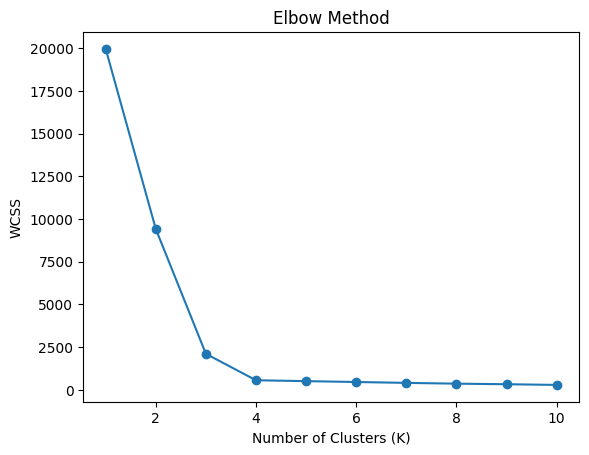

In [4]:
import matplotlib.pyplot as plt


plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

### Silhouette Score Python
- A metric that measures how similar a point is to its own cluster compared with other clusters.
- Silhouette Score is usually more informative because it considers both cluster compactness and separation.

```bash
K-Means-এ আগে থেকেই K নির্বাচন করতে হয়।
K নির্বাচন করার জন্য প্রধান দুইটি পদ্ধতি:
Elbow Method
Silhouette Score
Elbow Method:
বিভিন্ন K দিয়ে model train করি।
প্রতিটির WCSS বের করি।
যেখানে WCSS কমার হার ধীর হয়ে যায়, সেটাই best K।
Silhouette Score:
নিজের cluster-এর সাথে similarity এবং অন্য cluster থেকে distance পরিমাপ করে।
Score যত বেশি, clustering তত ভালো।
```

In [5]:
from sklearn.metrics import silhouette_score


scores=[]


for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(X)

    score = silhouette_score(
        X,
        labels
    )

    scores.append(score)

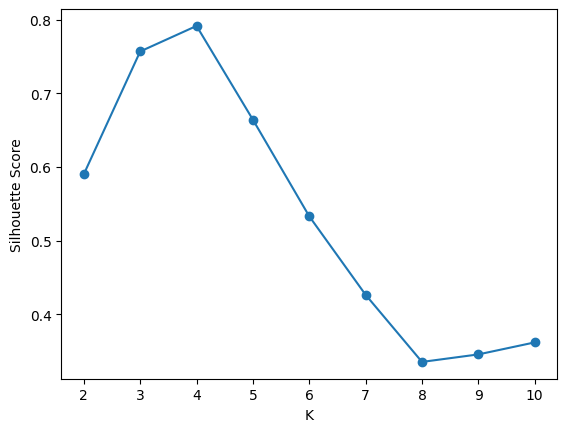

In [6]:
plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Silhouette Score")

plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


best_k = None
best_score = -1


for k in range(2,10):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels=model.fit_predict(X_scaled)


    score=silhouette_score(
        X_scaled,
        labels
    )


    print(
        k,
        score
    )


    if score > best_score:

        best_score=score
        best_k=k


print(
    "Best K:",
    best_k
)

2 0.55773379731114
3 0.743594601645247
4 0.7974739889632732
5 0.6742245911933695
6 0.5513465668253311
7 0.5522514262516711
8 0.4392474443670678
9 0.3448628037469148
Best K: 4


### K-Means vs Hierarchical Clustering

| K-Means              | Hierarchical          |
| -------------------- | --------------------- |
| Need K beforehand    | No need initially     |
| Faster               | Slower                |
| Works for large data | Better for small data |
| Uses centroid        | Uses distance tree    |
| Iterative            | Tree based            |

### K-Means vs DBSCAN

| K-Means               | DBSCAN           |
| --------------------- | ---------------- |
| Need K                | No K required    |
| Sensitive to outliers | Handles outliers |
| Spherical clusters    | Arbitrary shapes |
| Fast                  | Slower           |
| Centroid based        | Density based    |

### Handling Large Datasets
- Mini-Batch K-Means

```bash
from sklearn.cluster import MiniBatchKMeans


model = MiniBatchKMeans(
    n_clusters=5,
    batch_size=100
)


import numpy as np
def distance(a,b):
    return np.sqrt(np.sum((a-b)**2))
```


| Concept        | Answer                |
| -------------- | --------------------- |
| Type           | Unsupervised Learning |
| Purpose        | Grouping similar data |
| Algorithm      | Centroid-based        |
| Input          | Features only         |
| Output         | Cluster labels        |
| Distance       | Euclidean             |
| Optimization   | Minimize WCSS         |
| Centroid       | Mean of points        |
| Initialization | K-Means++             |
| K Selection    | Elbow/Silhouette      |
| Sensitive to   | Outliers, Scaling     |
| Complexity     | O(n×k×i×d)            |
| Large Data     | MiniBatchKMeans       |

- K-Means = Centroid + Distance + WCSS Minimization + Unsupervised Learning

### What is K-Means++?

- K-Means++ is an improved initialization technique.
- Instead of randomly choosing centroids:
- It chooses initial centroids that are far away from each other.